# Multiouput and SHAP Values

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor 
from sklearn.metrics import r2_score, mean_squared_error

import shap 
import matplotlib.pyplot as plt

/Users/murodjongafforov/Desktop/mp2_8th_lesson/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load dataset

In [2]:
df = pd.read_csv("human_cognitive_performance.csv")
df_copy = df.copy()

In [3]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             80000 non-null  str    
 1   Age                 80000 non-null  int64  
 2   Gender              80000 non-null  str    
 3   Sleep_Duration      80000 non-null  float64
 4   Stress_Level        80000 non-null  int64  
 5   Diet_Type           80000 non-null  str    
 6   Daily_Screen_Time   80000 non-null  float64
 7   Exercise_Frequency  80000 non-null  str    
 8   Caffeine_Intake     80000 non-null  int64  
 9   Reaction_Time       80000 non-null  float64
 10  Memory_Test_Score   80000 non-null  int64  
 11  Cognitive_Score     80000 non-null  float64
 12  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), str(4)
memory usage: 7.9 MB


In [4]:
# Identifying tartget columns 
target_cols = ["Cognitive_Score", "Memory_Test_Score"] # both are metrics of brain activity and mental capacity.

X = df_copy.drop(columns = ["User_ID", "AI_Predicted_Score"] + target_cols)
y = df[target_cols]

print("X shakli: ", X.shape)
print("y shakli: ", y.shape)

X shakli:  (80000, 9)
y shakli:  (80000, 2)


# train/test split stage

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [6]:
categorical_features = ["Gender", "Diet_Type", "Exercise_Frequency"]
numerical_features = [col for col in X.columns if col not in categorical_features] 

# an alternative way:
# categorical_features = X.select_dtypes(inlcude = ["int64", "float64"]).columns.tolist()
# numerical_features = X.select_dtypes(inlcude = ["object", "string"]).columns.tolist()

# Pipeline stage 

In [7]:

numeric_transformer = Pipeline(steps = [("scaler", MinMaxScaler())])
categorical_transfomer = Pipeline(steps = [
    ("encoder", OrdinalEncoder(handle_unknown = "use_encoded_value", unknown_value = -1))
])


# Preprocessor --> ColumnTransfomer

In [8]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer,numerical_features),
        ("cat", categorical_transfomer, categorical_features)
    ]
)

# To use MultiOutputRegressor we choose an algorithm

In [10]:
base_model = LinearRegression()
multi_output_model = MultiOutputRegressor(base_model)
base_model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Pipeline stage 

In [11]:
pipeline = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("regressor", multi_output_model)
])

pipeline 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

In [12]:
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','Gender','Sleep_Duration',...,'Exercise_Frequency', 'Caffeine_Intake','Reaction_Time']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [13]:
y_pred = pipeline.predict(X_test)

for i, target in enumerate(target_cols):
    mse = mean_squared_error(y_test[target], y_pred[:, i])
    r2 = r2_score(y_test[target], y_pred[:, i])
    print(f"{target} -> MSE: {mse:.4f}, R2: {r2:.4f}")

Cognitive_Score -> MSE: 105.2375, R2: 0.8003
Memory_Test_Score -> MSE: 300.4572, R2: -0.0003


# SHAP VALUES

In [14]:
# Evaluation of train and test 

y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

print("Train R2: ", r2_score(y_train, y_train_pred))
print("Test R2: ", r2_score(y_test, y_test_pred))


Train R2:  0.40064472009775065
Test R2:  0.4000253776561164



=== SHAP Analysis for: Cognitive_Score ===


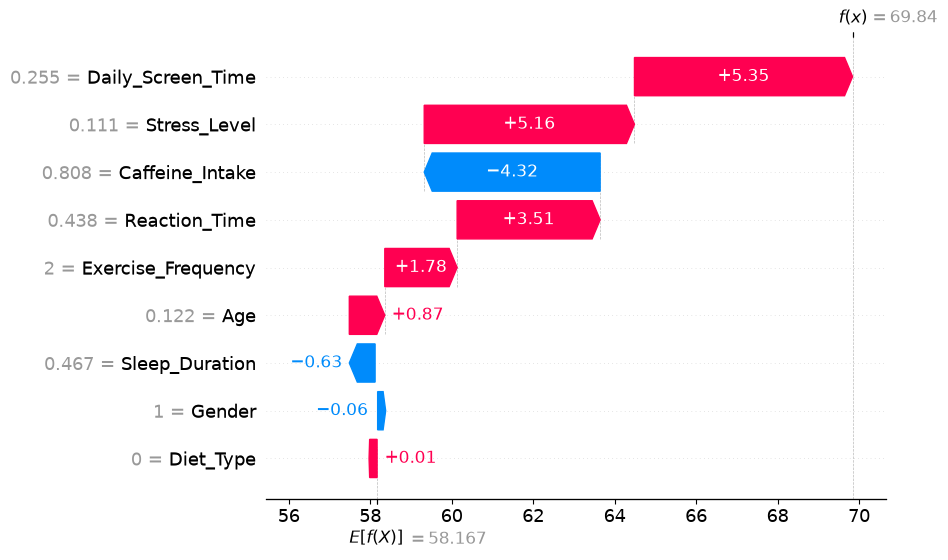


=== SHAP Analysis for: Memory_Test_Score ===


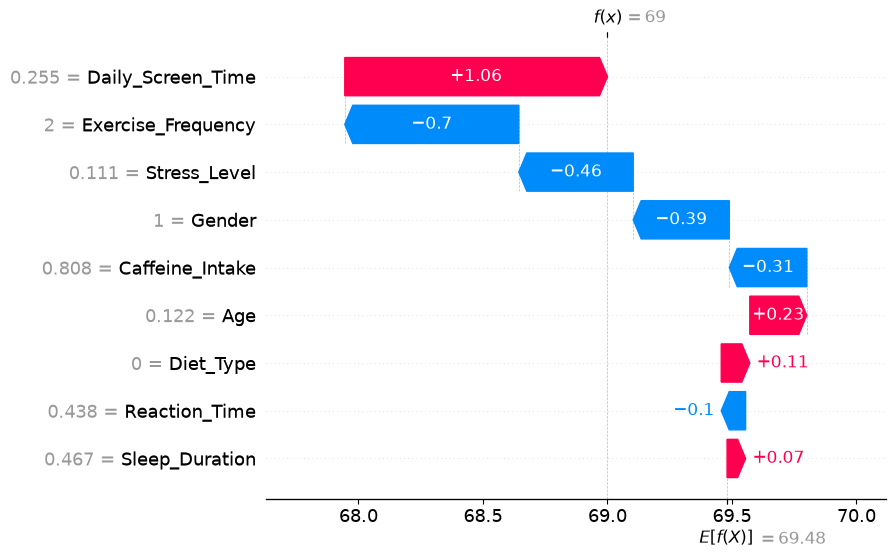

In [13]:
# SHAP Exaplanation 
X_test_preprocessed = pipeline.named_steps["preprocessor"].transform(X_test)
multi_regressor = pipeline.named_steps["regressor"]

for idx,target_name in enumerate(target_cols):
    print(f"\n=== SHAP Analysis for: {target_name} ===")

    multi_i = multi_regressor.estimators_[idx]
    explainer = shap.TreeExplainer(multi_i)
    shap_values = explainer.shap_values(X_test_preprocessed)
    base_value = float(np.array(explainer.expected_value).ravel()[0])

    shap.waterfall_plot(shap.Explanation(
        values = shap_values[0],
        base_values = base_value,
        data = X_test_preprocessed[0],
        feature_names = list(numerical_features) + list(categorical_features)
    ))

# === SHAP Analysis for: Cognitive_Score ===

Xbaseline = 58.167, Xfinal = 69.84 

Where they came from? -> 58.167 + 5.35 + 5.16 - 4.32 + 3.51 + 1,78 + 0.87 - 0.63 - 0.06 + 0.01 = 69.84

# === SHAP Analysis for: Memory_Test_Score ===

Xbaseline = 69.48, Xfinal = 69

Where they came from? -> 69.48 + 1.06 - 0.7 - 0.46 - 0.39 - 0.31 + 0.23 + 0.11 - 0.1 + 0.07 = 69



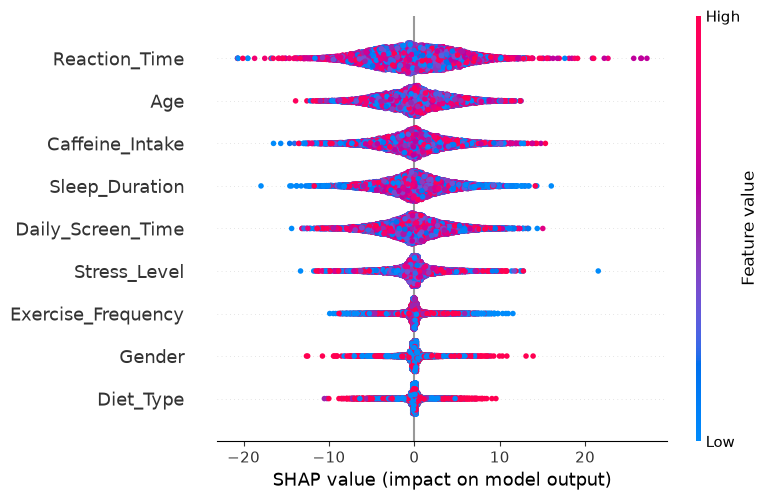

In [14]:
shap.summary_plot(shap_values, X_test_preprocessed, feature_names = list(numerical_features) + list(categorical_features))

# === SHAP Value for Linear Regression 

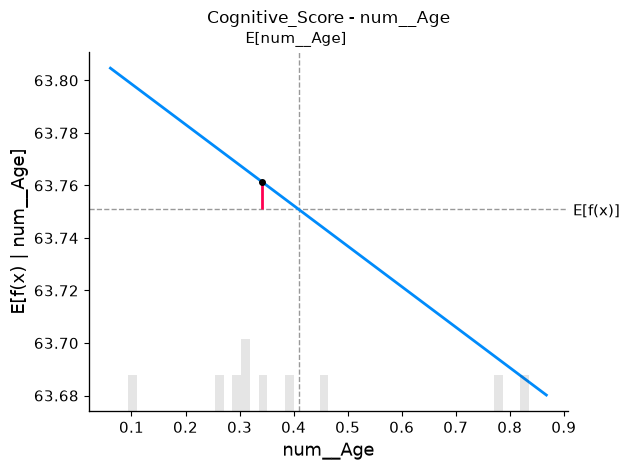

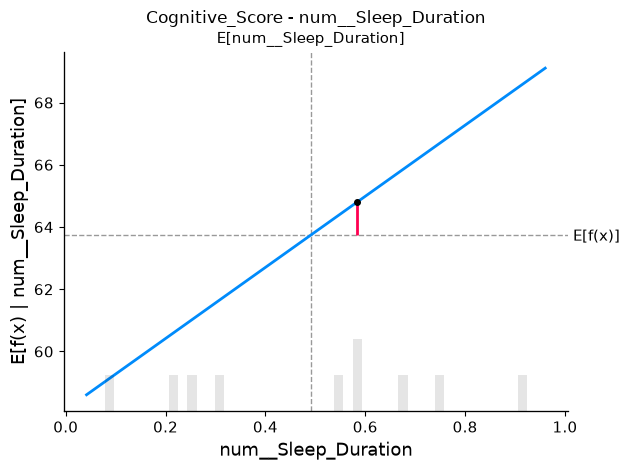

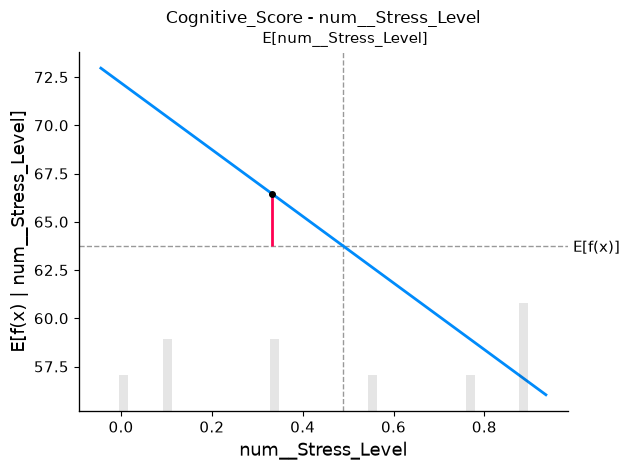

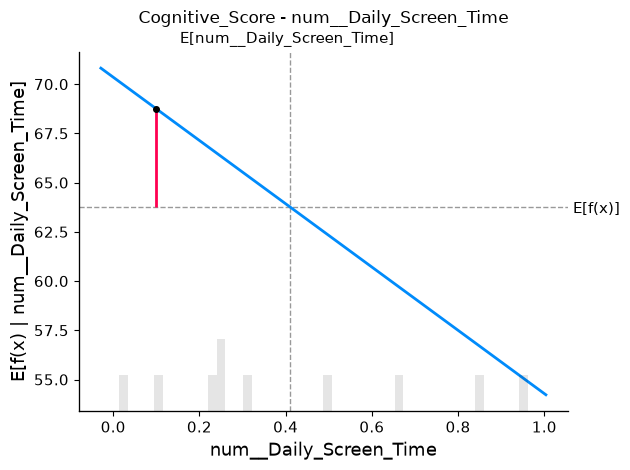

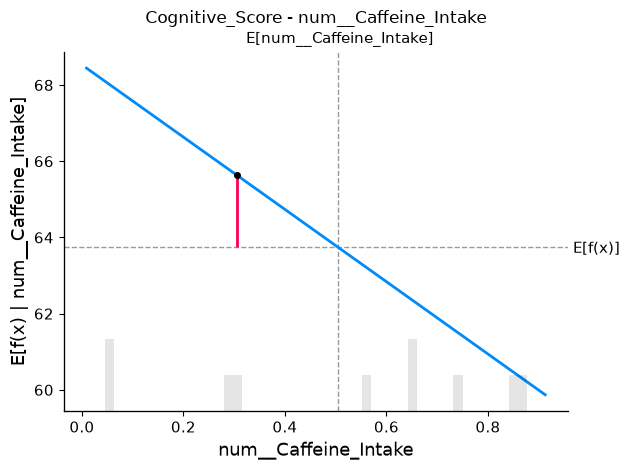

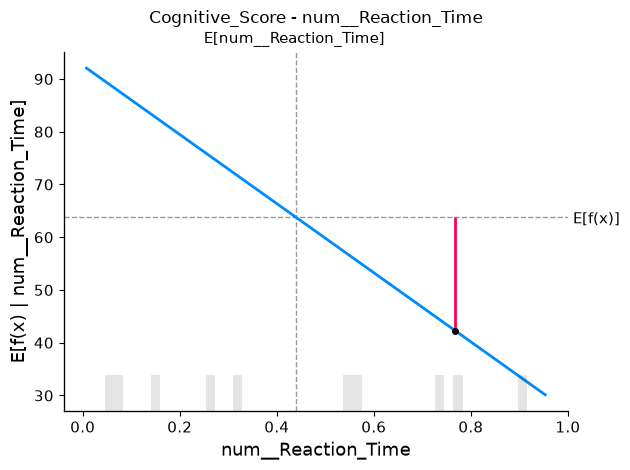

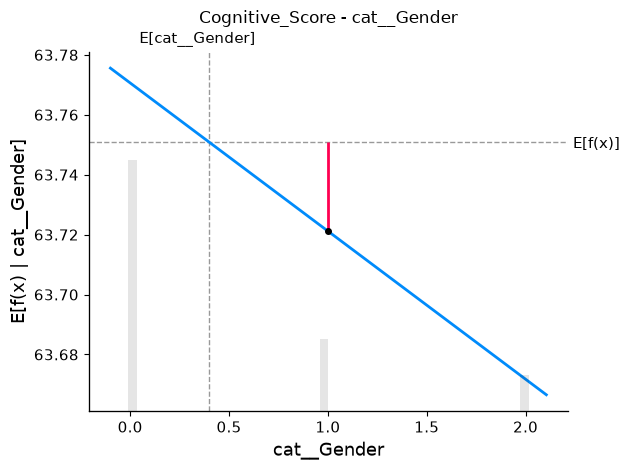

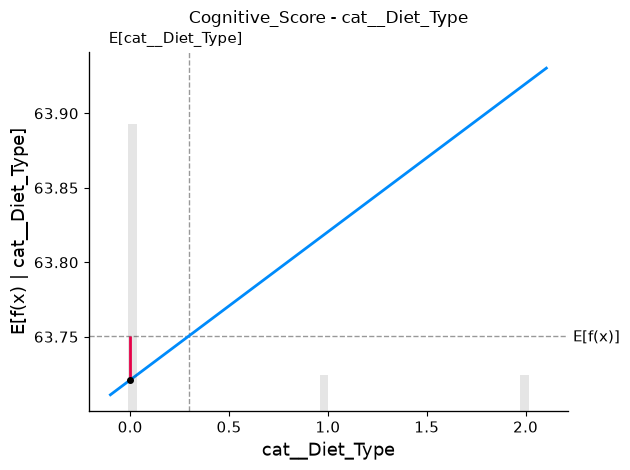

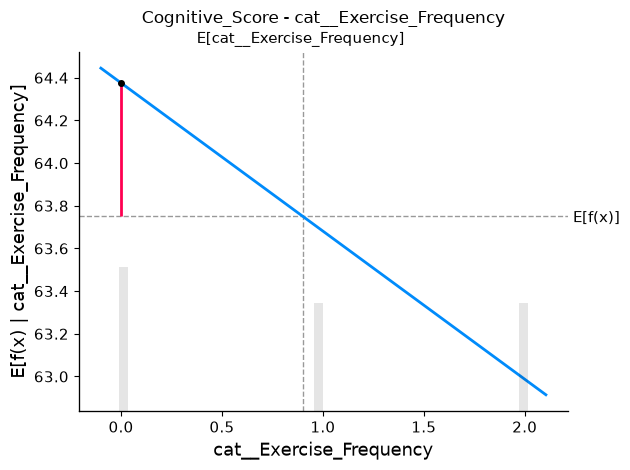

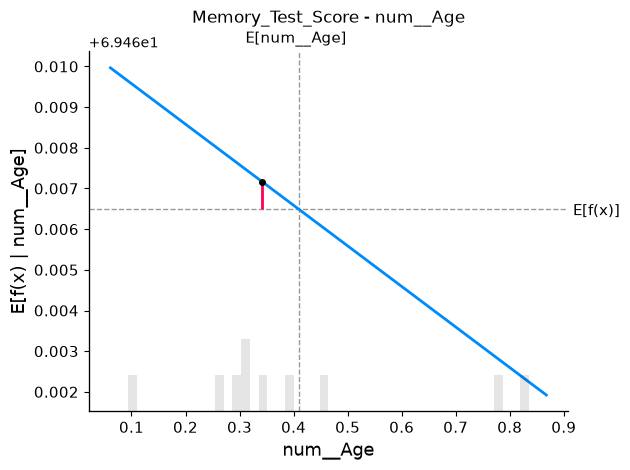

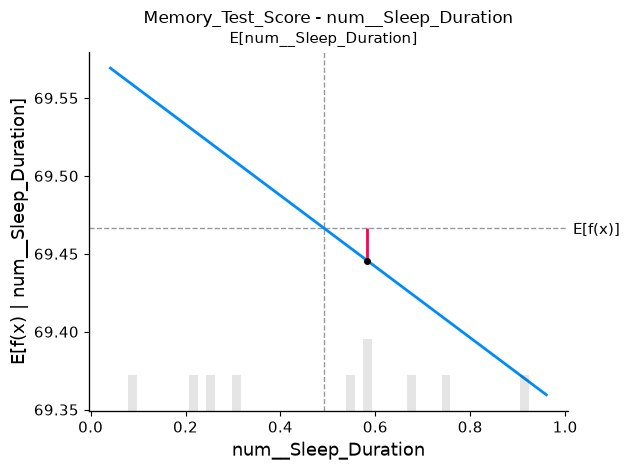

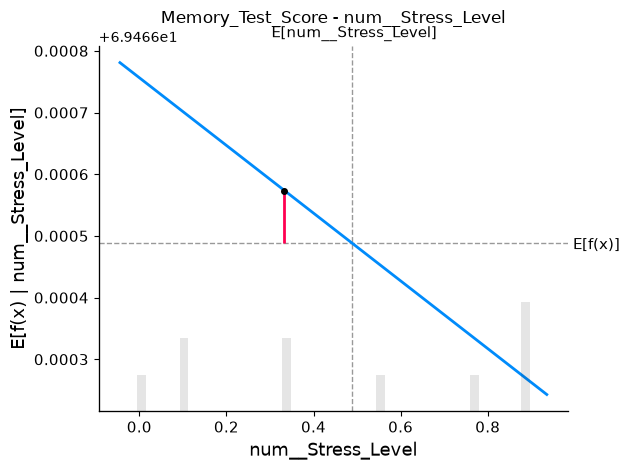

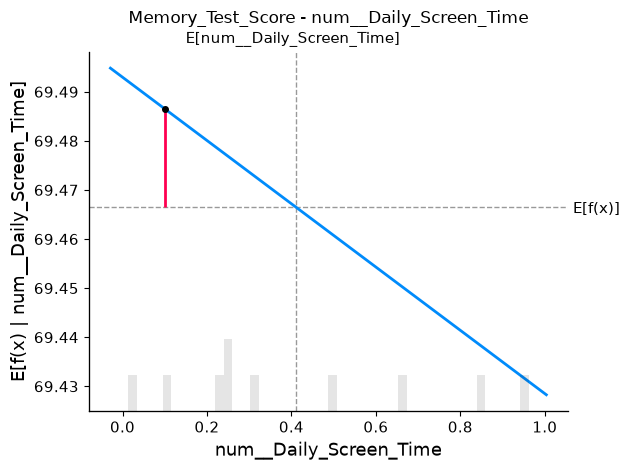

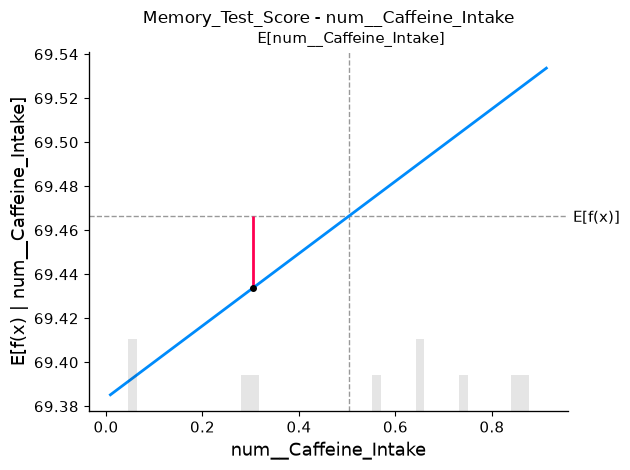

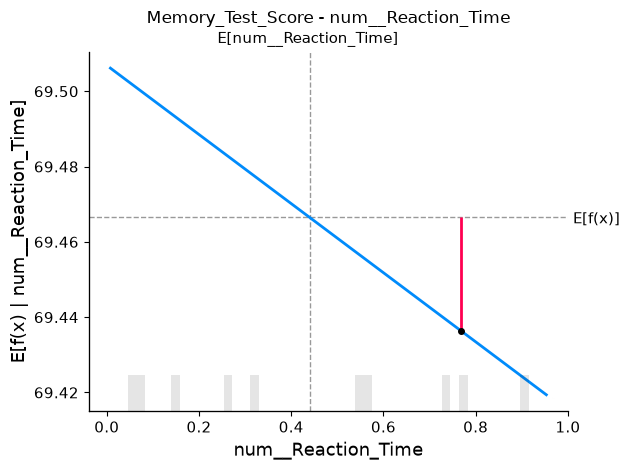

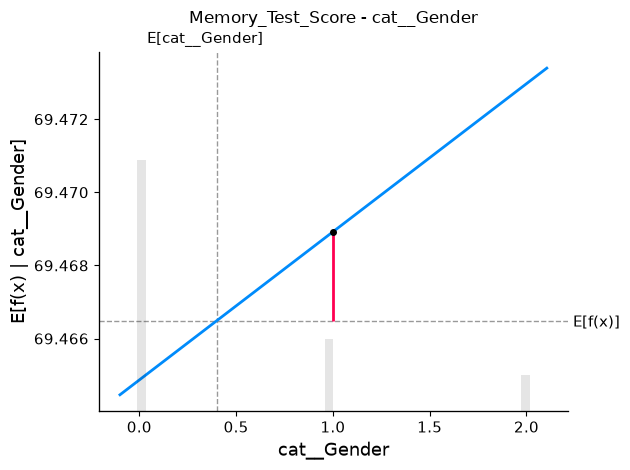

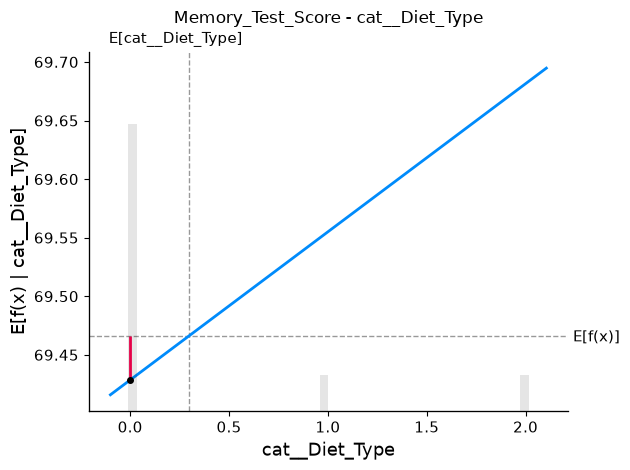

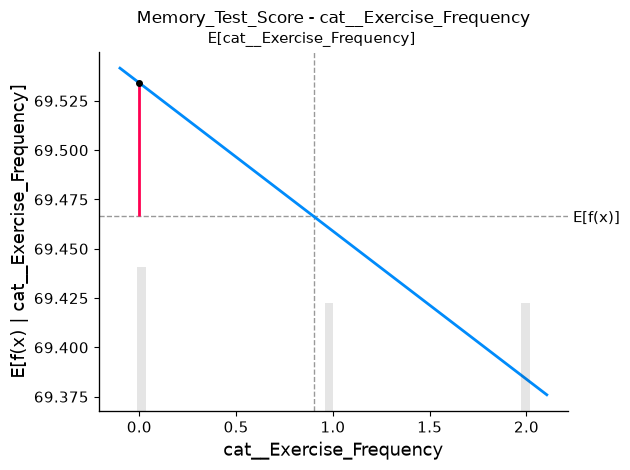

In [23]:
import shap
import numpy as np
import matplotlib.pyplot as plt

feature_names = list(
    pipeline.named_steps["preprocessor"].get_feature_names_out()
)

X_test_p = pipeline.named_steps["preprocessor"].transform(X_test)

X_sample = shap.sample(X_test_p, 10, random_state=42)

if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()


for idx, target in enumerate(target_cols):

    model = pipeline.named_steps["regressor"].estimators_[idx]

    explainer = shap.LinearExplainer(model, X_sample)
    shap_values = explainer(X_sample)

    sample_ind = 0

    for feat in feature_names:

        sv = shap_values[sample_ind:sample_ind + 1, :]

        # Important fix
        sv.base_values = float(np.ravel(sv.base_values)[0])

        shap.plots.partial_dependence(
            feat,
            model.predict,
            X_sample,
            feature_names=feature_names,
            shap_values=sv,
            feature_expected_value=True,
            ice=False,
            show=False
        )

        plt.title(f"{target} - {feat}")
        plt.tight_layout()
        plt.show()
        plt.close("all")

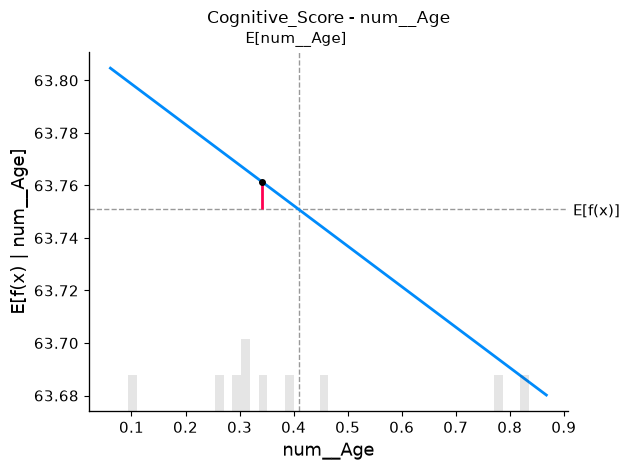

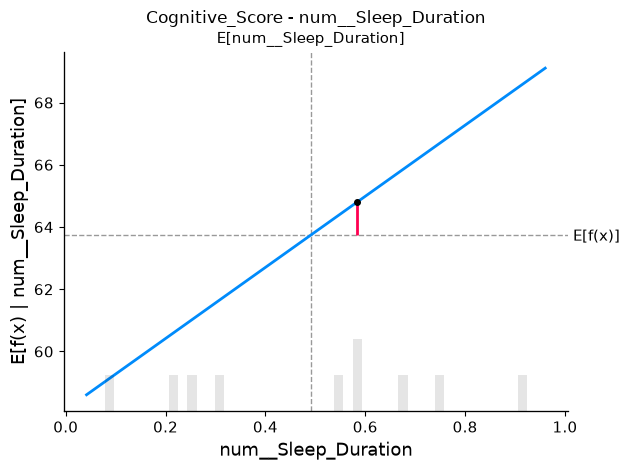

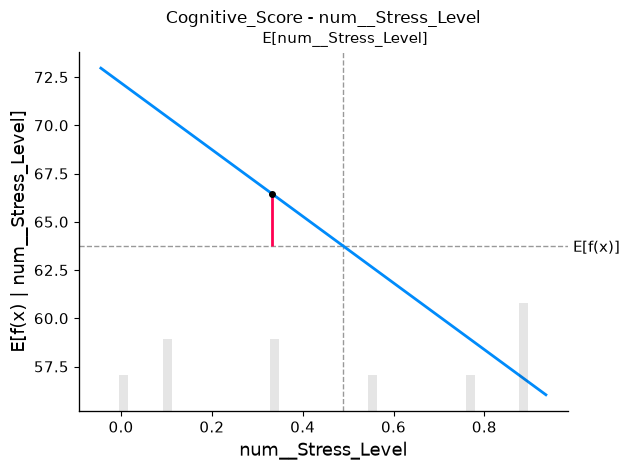

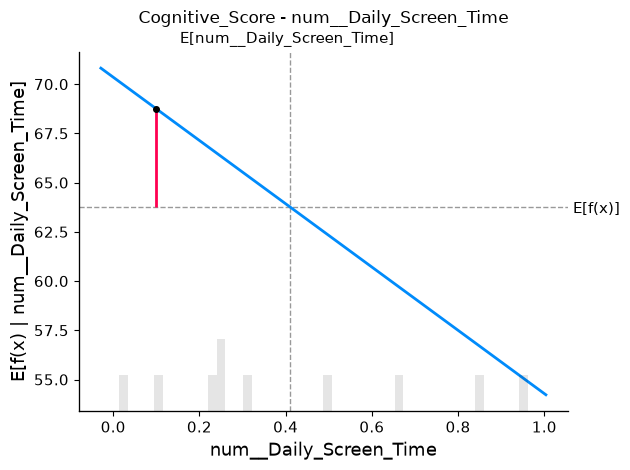

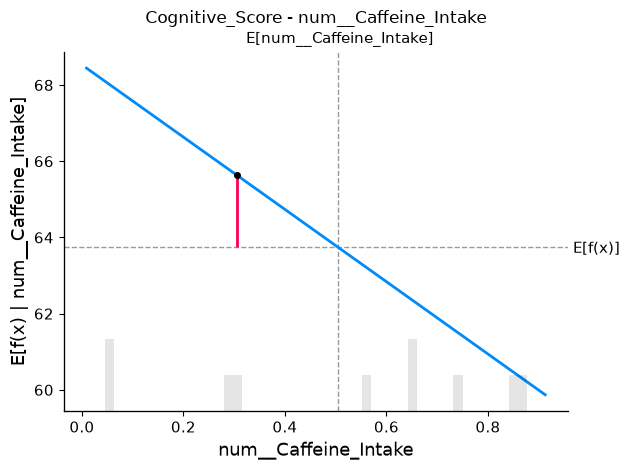

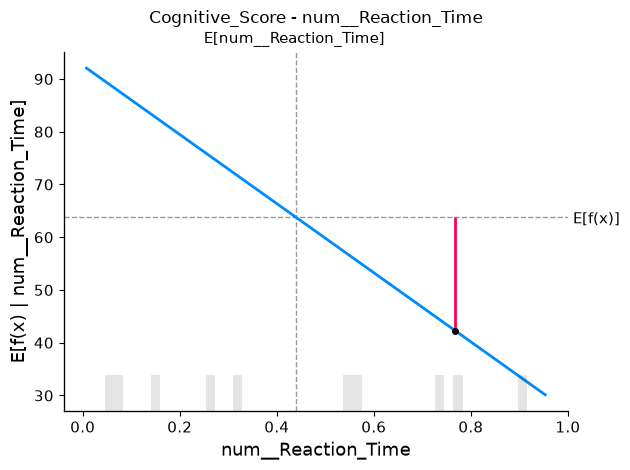

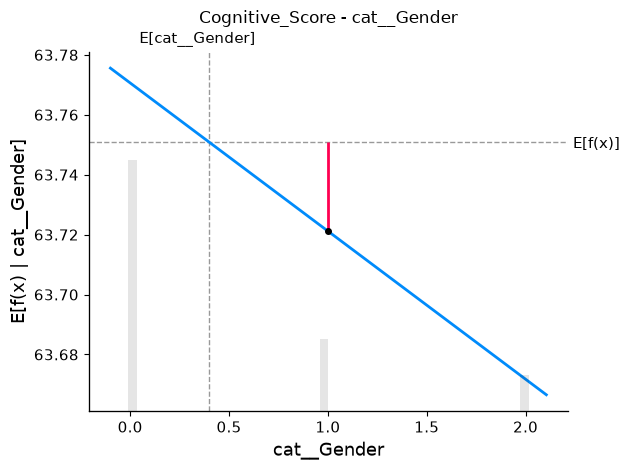

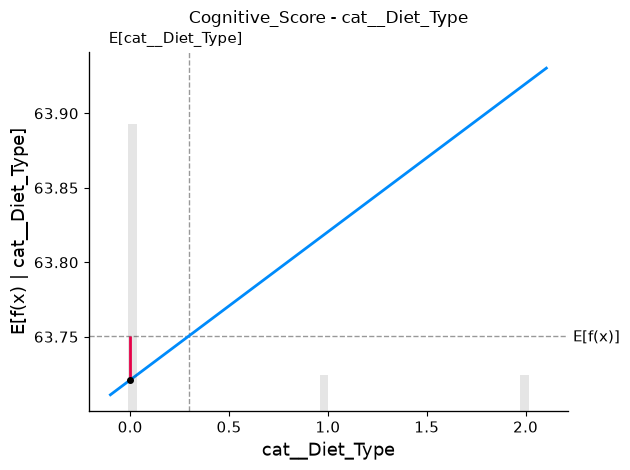

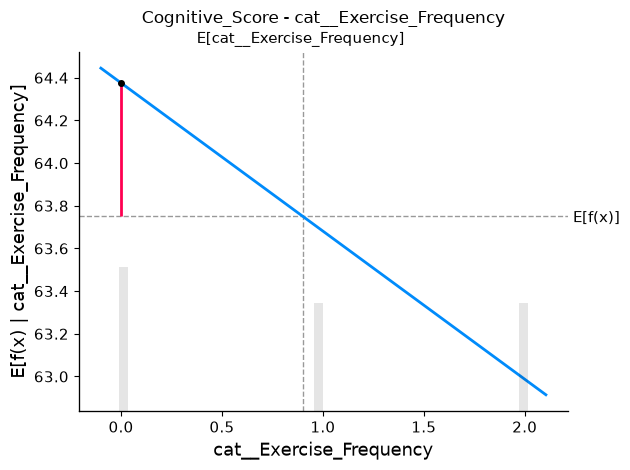

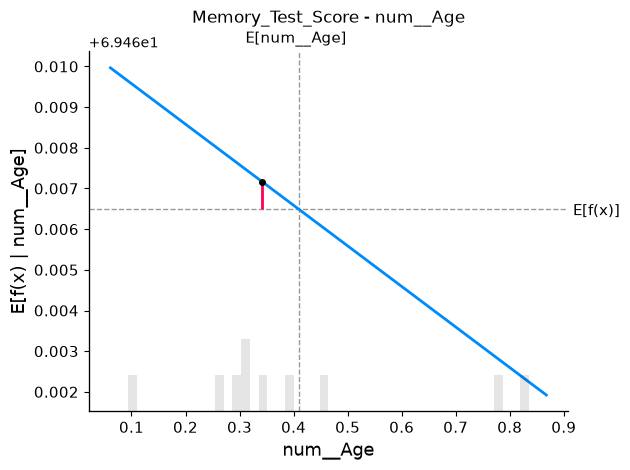

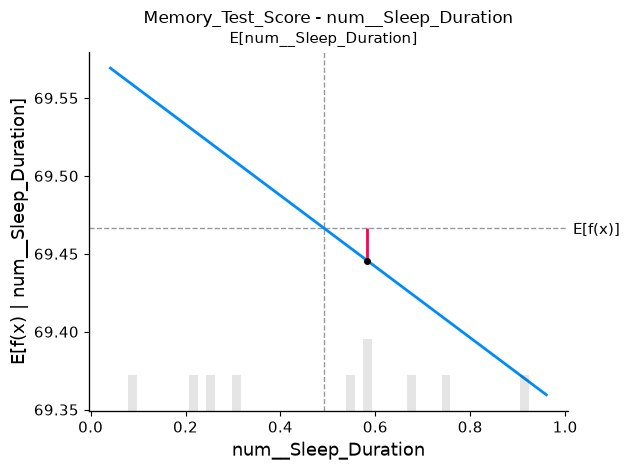

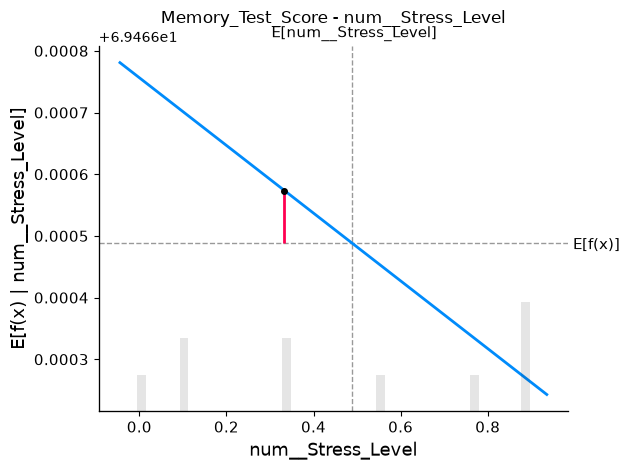

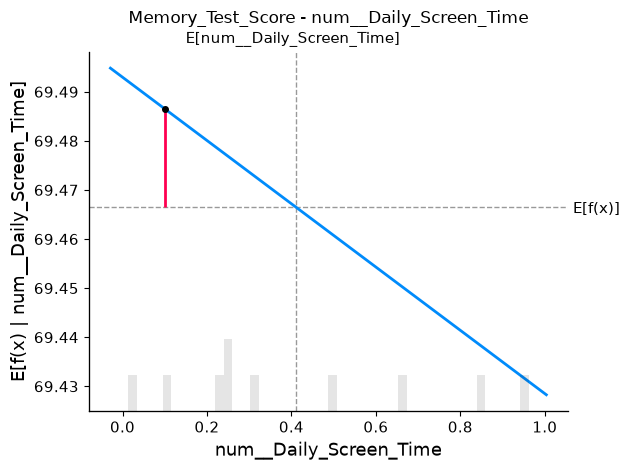

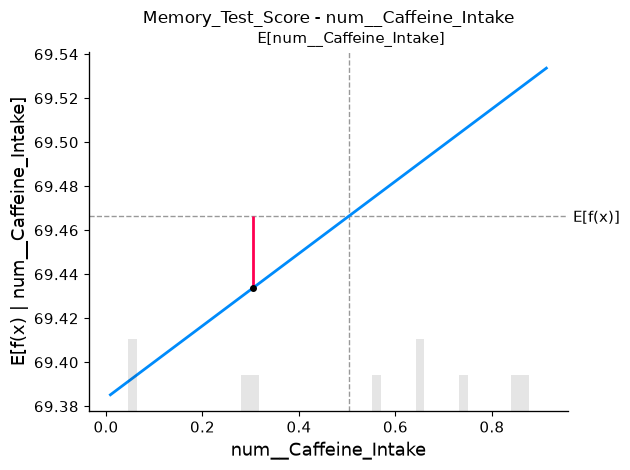

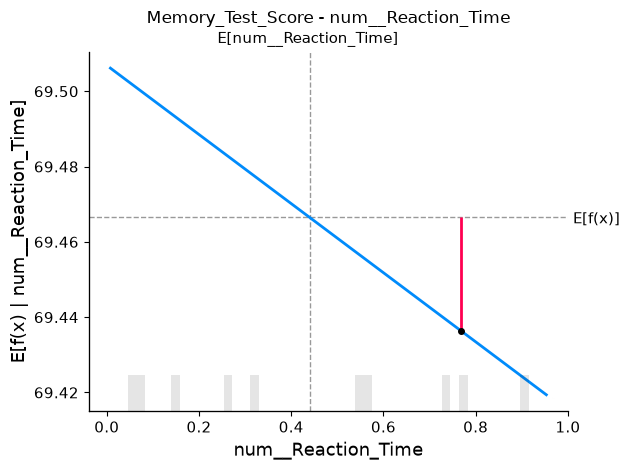

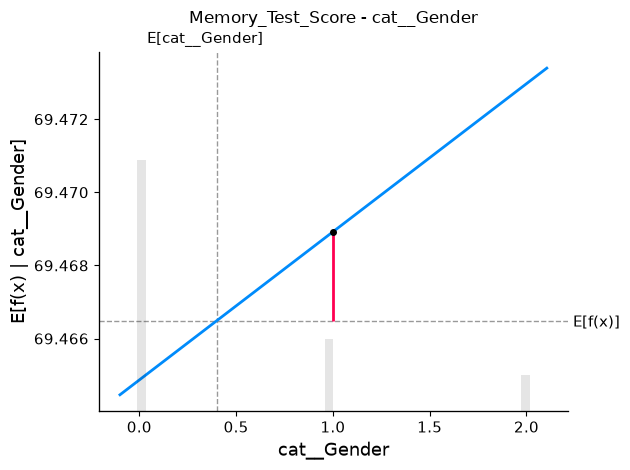

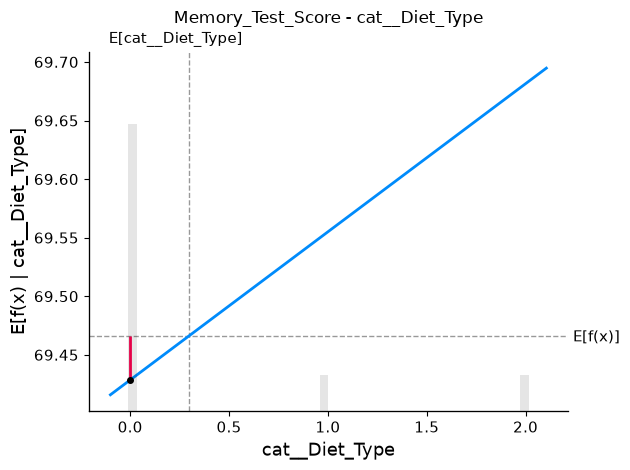

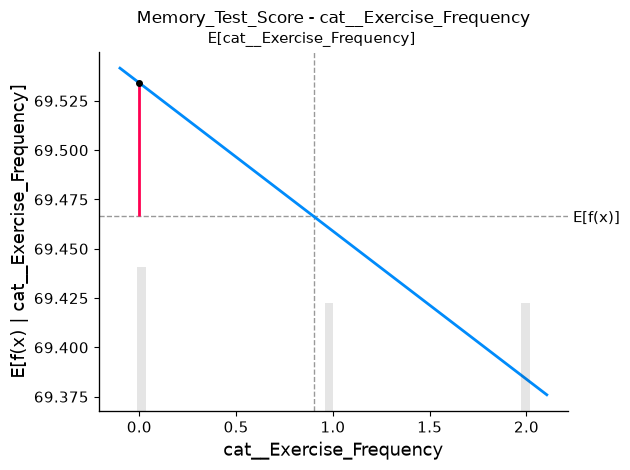

In [25]:
import shap
import numpy as np
import matplotlib.pyplot as plt

feature_names = list(
    pipeline.named_steps["preprocessor"].get_feature_names_out()
)

X_test_p = pipeline.named_steps["preprocessor"].transform(X_test)

X_sample = shap.sample(X_test_p, 10, random_state=42)

if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()
idx = 1
target = target_cols[idx]

for idx, target in enumerate(target_cols):

    model = pipeline.named_steps["regressor"].estimators_[idx]

    explainer = shap.LinearExplainer(model, X_sample)
    shap_values = explainer(X_sample)

    sample_ind = 0

    for feat in feature_names:

        sv = shap_values[sample_ind:sample_ind + 1, :]

        # Important fix
        sv.base_values = float(np.ravel(sv.base_values)[0])

        shap.plots.partial_dependence(
            feat,
            model.predict,
            X_sample,
            feature_names=feature_names,
            shap_values=sv,
            feature_expected_value=True,
            ice=False,
            show=False
        )

        plt.title(f"{target} - {feat}")
        plt.tight_layout()
        plt.show()
        plt.close("all")

# OFFLINE TEST

In [26]:
import joblib
model_filename = "multioutput_goals_xG_model.joblib"
joblib.dump(pipeline, model_filename)
print(f"\n Model saved successfully as '{model_filename}'")


 Model saved successfully as 'multioutput_goals_xG_model.joblib'


In [27]:
import joblib 

pipeline = joblib.load("multioutput_goals_xG_model.joblib")

In [28]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
print(feature_names)

['num__Age' 'num__Sleep_Duration' 'num__Stress_Level'
 'num__Daily_Screen_Time' 'num__Caffeine_Intake' 'num__Reaction_Time'
 'cat__Gender' 'cat__Diet_Type' 'cat__Exercise_Frequency']


In [29]:
X_test_processed = pd.DataFrame(
    X_test_p,
    columns=feature_names
)

In [31]:
sample = X_test_processed.iloc[0].to_dict()
sample

{'num__Age': 0.12195121951219517,
 'num__Sleep_Duration': 0.4666666666666667,
 'num__Stress_Level': 0.1111111111111111,
 'num__Daily_Screen_Time': 0.2545454545454545,
 'num__Caffeine_Intake': 0.8076152304609218,
 'num__Reaction_Time': 0.4381109527738193,
 'cat__Gender': 1.0,
 'cat__Diet_Type': 0.0,
 'cat__Exercise_Frequency': 2.0}

In [32]:
user_input = [
    {
        'num__Age': 0.12,
        'num__Sleep_Duration': 0.46,
        'num__Stress_Level': 0.14,
        'num__Daily_Screen_Time': 0.25,
        'num__Caffeine_Intake': 0.80,
        'num__Reaction_Time': 0.43,
        'cat__Gender': 1.0,
        'cat__Diet_Type': 0.0,
        'cat__Exercise_Frequency': 2.0
        
    },
     {
            'num__Age': 0.23,
            'num__Sleep_Duration': 0.55,
            'num__Stress_Level': 0.13,
            'num__Daily_Screen_Time': 0.45,
            'num__Caffeine_Intake': 0.80,
            'num__Reaction_Time': 0.60,
            'cat__Gender': 1.0,
            'cat__Diet_Type': 0.0,
            'cat__Exercise_Frequency': 2.0
            
        },
     {
            'num__Age': 0.23,
            'num__Sleep_Duration': 0.46,
            'num__Stress_Level': 0.89,
            'num__Daily_Screen_Time': 0.33,
            'num__Caffeine_Intake': 0.44,
            'num__Reaction_Time': 0.66,
            'cat__Gender': 1.0,
            'cat__Diet_Type': 0.0,
            'cat__Exercise_Frequency': 2.0
            
        }
]

df_input = pd.DataFrame(user_input)

In [36]:

# Original training bo'lgan ustunlar (
# feature_names_in_ --> model yoki pipeline fit() qilinganda unga kirgan original input column nomlarini eslab qolish.)
loaded_pipeline = joblib.load("multioutput_goals_xG_model.joblib")
required_cols = list(loaded_pipeline.feature_names_in_)

print("Required columns:")
print(required_cols)

# bunda asosan training bo'lgan ustunlarni olib X_testdagi required_colsni olish
X_features = X_test[required_cols]

predictions = loaded_pipeline.predict(X_features)


# 5. DataFrame ko'riishiga olib keldik
df_results = pd.DataFrame(
    predictions,
    columns=[f"Prediction__{target}" for target in target_cols]
)

print("\nPredictions:")
# faqat 5 tasini chiqarish
print(df_results.head())

Required columns:
['Age', 'Gender', 'Sleep_Duration', 'Stress_Level', 'Diet_Type', 'Daily_Screen_Time', 'Exercise_Frequency', 'Caffeine_Intake', 'Reaction_Time']

Predictions:
   Prediction__Cognitive_Score  Prediction__Memory_Test_Score
0                    68.969051                      69.417307
1                    60.149604                      69.373518
2                    61.126107                      69.386015
3                    54.714980                      69.578131
4                    75.046522                      69.392995
